In [2]:
import sys
from pathlib import Path

parent_folder = Path.cwd().parent
if str(parent_folder) not in sys.path:
    sys.path.append(str(parent_folder))
    
import warnings
warnings.filterwarnings('ignore')

import scienceplots

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('science')
import analysis_functional as a

PyHEADTAIL v1.16.5


# 1D sweep

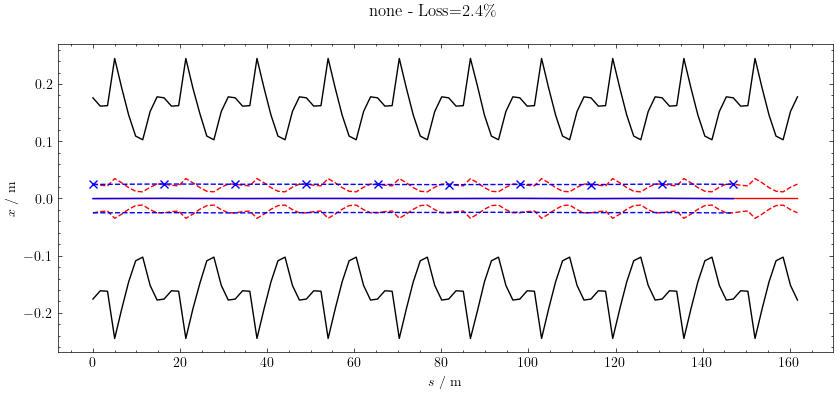

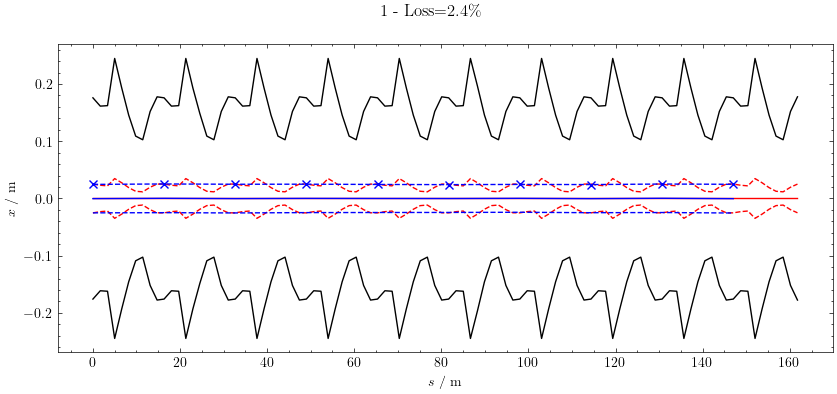

In [308]:
enlargements = [0.5, 0.6, 0.7, 0.8, 0.9, 1, 1.5, 2, 3, 'none']
enlargements = [0.6, 0.7, 0.8, 0.9, 1, 1.5, 2, 3, 'none']
enlargements = [0.7, 0.8, 0.9, 1, 1.5, 2, 3, 'none']
#enlargements = [0.8, 0.9, 1, 2, 'none']
enlargements = ['none', 1]
Qxs = []
Qys = []
qxs = []
qys = []
survivor_masks = []

turn=2
for en in enlargements:#
    res = a.load_simulation(f'data/sweep_ensemble/{en}.h5')
    Qx, Qy = a.get_tunes(res.x, res.y, res.px, res.py, res.twiss_df_at_mon, res.survivor_mask)
    Qxs.append(Qx)
    Qys.append(Qy)
    qxs.append(res.qx)
    qys.append(res.qy)
    #print(en)
    #print(np.sum(res.survivor_mask))
    #survivor_masks.append(res.survivor_mask)
    if en != 'none0':
        fig, ax = plt.subplots(figsize=(10,4))
        ax.plot(res.aper_df['s'], res.aper_df['x'].values + res.aper_df['Lx'].values, c='k', label='Beam Pipe')
        ax.plot(res.aper_df['s'], res.aper_df['x'].values - res.aper_df['Lx'].values, c='k')
        ax.plot(res.aper_df['s'], res.beam_df['x0'].values + res.beam_df['sigma_x'].values, c='r', ls='--', label=r'$1\sigma$ (from Twiss)')
        ax.plot(res.aper_df['s'], res.beam_df['x0'].values - res.beam_df['sigma_x'].values, c='r', ls='--',)
        ax.plot(res.aper_df['s'], res.beam_df['x0'].values, c='r', label='Closed orbit')
        
        x = res.x.T[10*turn:10*(turn+1)]
        centroid_x = np.mean(x, axis=1)
        std_x = np.std(x, axis=1)
        ax.plot(res.twiss_df_at_mon['s'], centroid_x, c='b', label='Ensemble centroid')
        ax.plot(res.twiss_df_at_mon['s'], centroid_x+std_x, c='b', ls='--', marker='x', label=r'Ensemble $1\sigma$')
        ax.plot(res.twiss_df_at_mon['s'], centroid_x-std_x, c='b', ls='--')
        ax.set_xlabel('$s$ / m')
        ax.set_ylabel('$x$ / m')
        fig.suptitle(f'{en} - Loss={(1000-np.sum(res.survivor_mask))/10}\%')
        plt.show()

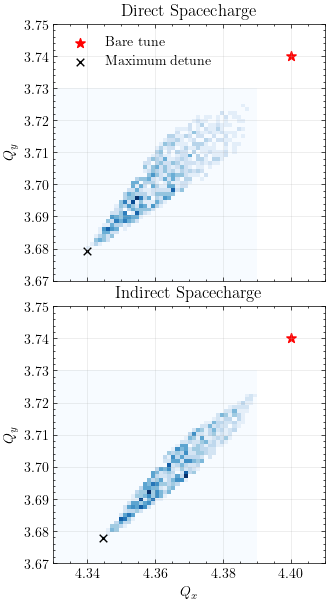

In [309]:
fig,axs = plt.subplots(2, figsize=(3.5,7), sharex=True)
fig.subplots_adjust(hspace=0.1)
for i in [0,1]:
    axs[i].hist2d(Qxs[i], Qys[i], bins=50, cmap='Blues', range=([4.33,4.39], [3.67,3.73]))
    axs[i].scatter(qxs[i], qys[i], marker='*', c='r', s=50, label='Bare tune')
    axs[i].scatter(min(Qxs[i]), min(Qys[i]), marker='x', c='k', s=30, label='Maximum detune')

    axs[i].set_xlim(4.33,4.41)
    axs[i].set_ylim(3.67,3.75)
axs[0].grid(alpha=0.3)
axs[1].grid(alpha=0.3)
axs[0].legend(loc='upper left')

axs[0].set_title('Direct Spacecharge')
axs[1].set_title('Indirect Spacecharge')

axs[0].set_ylabel('$Q_y$')
axs[1].set_xlabel('$Q_x$')
axs[1].set_ylabel('$Q_y$')
plt.savefig('footprints.pdf', bbox_inches='tight')

61.0
70.0
68.0
70.0
71.0
88.0
108.0
95.0


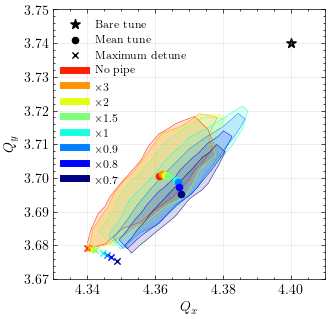

In [301]:
fig, ax = plt.subplots(figsize=(3.5, 3.5))

cmap = plt.get_cmap('jet')
n_en = len(enlargements)

ax.scatter(qxs[0], qys[0], marker='*', c='k', s=50, label='Bare tune')
ax.scatter([], [], marker='o', c='k', s=20, label='Mean tune')
ax.scatter([], [], marker='x', c='k', s=20, label='Maximum detune')
for i, en in enumerate(enlargements[::-1]):
    mask = ~np.isnan(Qxs[::-1][i]) & ~np.isnan(Qys[::-1][i])
    
    counts, xedges, yedges = np.histogram2d(Qxs[::-1][i][mask], Qys[::-1][i][mask], bins=10)
    extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]
    
    max_val = np.max(counts)
    print(max_val)
    levels = [0.3 * max_val, max_val]
    #levels = [1.5, max_val]
    
    color = cmap((n_en - 1 - i) / n_en)
    ax.contourf(counts.T, levels=levels, extent=extent, colors=[color], alpha=0.15)
    ax.contour(counts.T, levels=[levels[0]], extent=extent, colors=[color], linewidths=0.3)
    if en=='none':
        ax.plot([], [], color=color, label='No pipe', lw=5)
    else:
        ax.plot([], [], color=color, label=rf'$\times${en}', lw=5)
    ax.scatter(np.mean(Qxs[::-1][i][mask]), np.mean(Qys[::-1][i][mask]), marker='o', c=color, s=20, zorder=10)
    ax.scatter(min(Qxs[::-1][i][mask]), min(Qys[::-1][i][mask]), marker='x', c=color, s=20, zorder=10)
ax.set_xlabel('$Q_x$')
ax.set_ylabel('$Q_y$')
ax.grid(alpha=0.3)
ax.legend(loc='upper left', fontsize=8)
ax.set_xlim(4.33, 4.41)
ax.set_ylim(3.67, 3.75)

plt.savefig('stacked_contours.pdf', bbox_inches='tight')

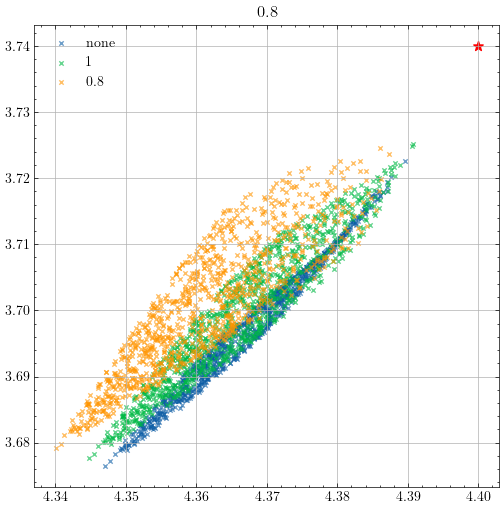

In [155]:
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(qxs[0], qys[0], marker='*', c='r', s=50)
ax.grid()
ax.set_title(en)
for i, en in enumerate(enlargements):
    ax.scatter(Qxs[i][::1], Qys[i][::1], marker='x', s=10, alpha=0.6, label=en)

ax.legend()